In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Data source
# https://www.kaggle.com/harlfoxem/housesalesprediction

from google.colab import files
uploaded = files.upload()

import io
seattle = pd.read_csv(io.BytesIO(uploaded['seattle_house_data.csv']))

In [ ]:
# EDA

seattle.isnull().sum()

id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

In [ ]:
seattle.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
id,21613.0,4.580302e+09,2.876566e+09,1.000102e+06,2.123049e+09,3.904930e+09,7.308900e+09,9.900000e+09
price,21613.0,5.400881e+05,3.671272e+05,7.500000e+04,3.219500e+05,4.500000e+05,6.450000e+05,7.700000e+06
bedrooms,21613.0,3.370842e+00,9.300618e-01,0.000000e+00,3.000000e+00,3.000000e+00,4.000000e+00,3.300000e+01
bathrooms,21613.0,2.114757e+00,7.701632e-01,0.000000e+00,1.750000e+00,2.250000e+00,2.500000e+00,8.000000e+00
sqft_living,21613.0,2.079900e+03,9.184409e+02,2.900000e+02,1.427000e+03,1.910000e+03,2.550000e+03,1.354000e+04
sqft_lot,21613.0,1.510697e+04,4.142051e+04,5.200000e+02,5.040000e+03,7.618000e+03,1.068800e+04,1.651359e+06
floors,21613.0,1.494309e+00,5.399889e-01,1.000000e+00,1.000000e+00,1.500000e+00,2.000000e+00,3.500000e+00
waterfront,21613.0,7.541757e-03,8.651720e-02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
view,21613.0,2.343034e-01,7.663176e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4.000000e+00
condition,21613.0,3.409430e+00,6.507430e-01,1.000000e+00,3.000000e+00,3.000000e+00,4.000000e+00,5.000000e+00


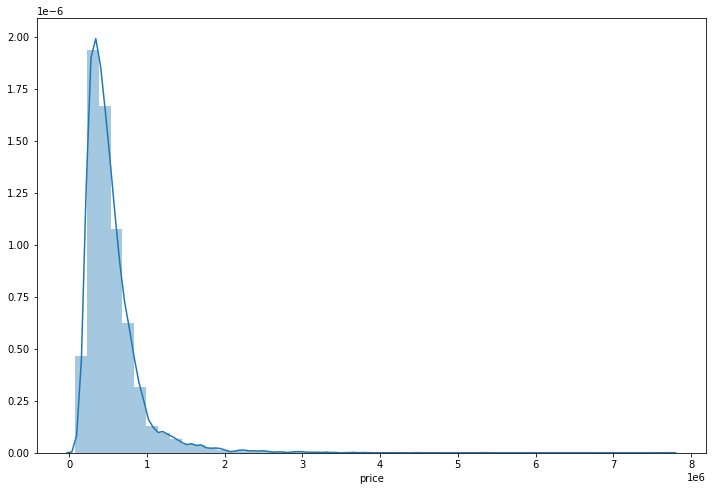

In [ ]:
plt.figure(figsize=(12,8))
sns.distplot(seattle['price'])

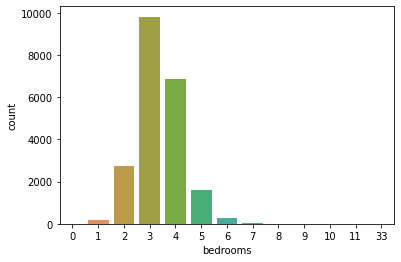

In [ ]:
sns.countplot(seattle['bedrooms'])

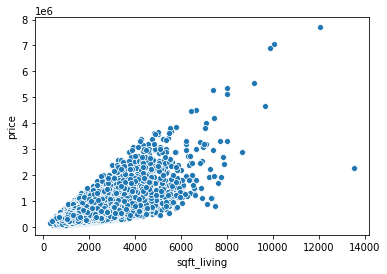

In [ ]:
plt.figure(figsize=(6,4))
sns.scatterplot(y='price',x='sqft_living',data=seattle)

In [ ]:
# Filter out top 1% of values (outliers)

seattle = seattle.sort_values('price',ascending=False).iloc[216:]

In [ ]:
seattle = seattle.drop(['id','date','long','lat','zipcode'],axis=1)

In [ ]:
seattle['renovated'] = seattle.yr_renovated.apply(lambda x: 1 if x > 2000 else 0)
seattle['age'] = 2016 - seattle.yr_built

In [ ]:
seattle.columns

Index(['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'grade', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'sqft_living15',
       'sqft_lot15', 'renovated', 'age'],
      dtype='object')

In [ ]:
seattle.drop(['yr_renovated', 'yr_built'], axis=1, inplace=True)

In [ ]:
seattle.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,sqft_living15,sqft_lot15,renovated,age
3281,1965000.0,5,3.75,3940,13738,1.5,0,3,4,9,3940,0,2370,13320,0,65
12577,1960000.0,4,4.00,4430,31353,2.0,0,0,3,12,4430,0,3900,35237,0,18
12283,1959000.0,5,4.50,6200,23373,3.0,0,1,4,11,5050,1150,3700,14486,0,28
1152,1955000.0,4,2.75,3120,7898,1.0,1,4,4,8,1560,1560,2630,13868,0,53
9175,1955000.0,3,1.75,3330,12566,1.0,1,4,4,8,1940,1390,3730,16560,0,56


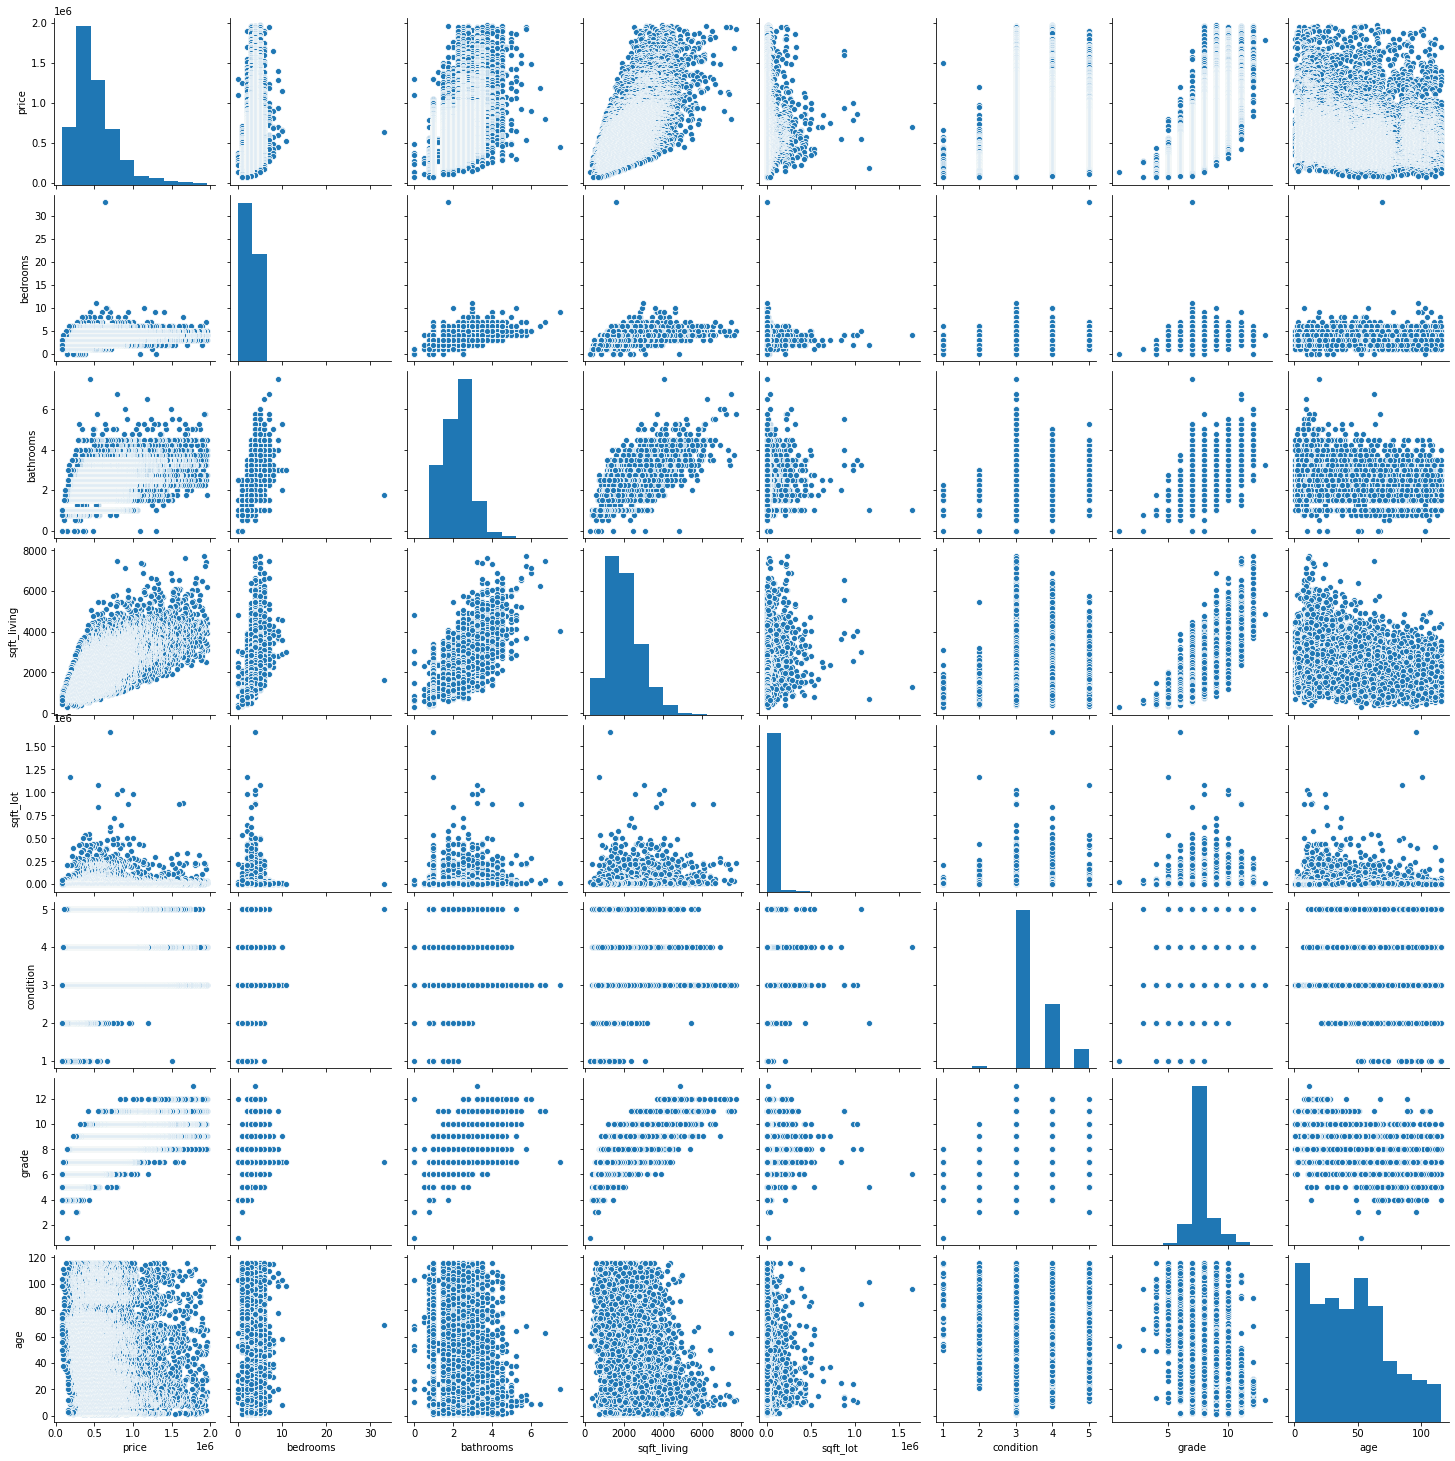

In [ ]:
sns.pairplot(seattle[['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 
                      'condition', 'grade', 'age']])

In [ ]:
seattle_filtered = seattle.query('bedrooms <10 & bathrooms < 6')

In [ ]:
X = seattle_filtered.drop('price',axis=1)
y = seattle_filtered['price']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=1)

In [ ]:
# Rescaling the data

from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

X_train= scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print('Training dataset shape: ', X_train.shape)
print('Test dataset shape: ', X_test.shape)

Training dataset shape:  (14970, 15)
Test dataset shape:  (6417, 15)


In [ ]:
# Defining model architecture

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation
from tensorflow.keras.optimizers import Adam

model = Sequential()

model.add(Dense(19,activation='relu'))
model.add(Dense(19,activation='relu'))
model.add(Dense(19,activation='relu'))
model.add(Dense(19,activation='relu'))
model.add(Dense(1))

model.compile(optimizer='adam',loss='mse')

In [ ]:
# Training the model

model.fit(x=X_train,y=y_train.values,
          validation_data=(X_test,y_test.values),
          batch_size=128,epochs=400)

Epoch 1/400
117/117 [==============================] - 0s 3ms/step - loss: 347552415744.0000 - val_loss: 353455374336.0000
Epoch 2/400
117/117 [==============================] - 0s 2ms/step - loss: 346005864448.0000 - val_loss: 348187951104.0000
Epoch 3/400
117/117 [==============================] - 0s 2ms/step - loss: 326257344512.0000 - val_loss: 303357198336.0000
Epoch 4/400
117/117 [==============================] - 0s 2ms/step - loss: 238240497664.0000 - val_loss: 165507792896.0000
Epoch 5/400
117/117 [==============================] - 0s 2ms/step - loss: 96708108288.0000 - val_loss: 55890026496.0000
Epoch 6/400
117/117 [==============================] - 0s 2ms/step - loss: 50354229248.0000 - val_loss: 49393917952.0000
Epoch 7/400
117/117 [==============================] - 0s 2ms/step - loss: 48645058560.0000 - val_loss: 48682373120.0000
Epoch 8/400
117/117 [==============================] - 0s 2ms/step - loss: 47900975104.0000 - val_loss: 47943933952.0000
Epoch 9/400
117/117 [===

In [ ]:
losses = pd.DataFrame(model.history.history)

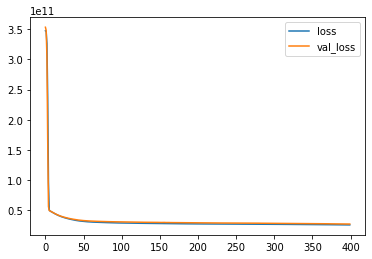

In [ ]:
losses.plot()

In [ ]:
# Evaluating model performance
# Regression metrics
# https://scikit-learn.org/stable/modules/model_evaluation.html#regression-metrics

from sklearn.metrics import mean_squared_error,mean_absolute_error,explained_variance_score

y_pred = model.predict(X_test)

print('Mean price: ', seattle['price'].mean())
print('Median price: ', seattle['price'].median())

print('MAE: ', mean_absolute_error(y_test,y_pred))
print('RMSE: ', np.sqrt(mean_squared_error(y_test,y_pred)))
print('Variance explained: ',explained_variance_score(y_test,y_pred))

Mean price:  518182.953591625
Median price:  450000.0
MAE:  116645.70117843078
RMSE:  164080.22491887904
Variance explained:  0.6651926549086812


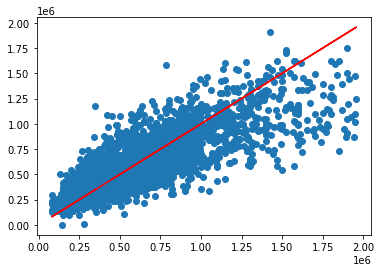

In [ ]:
# model predictions
plt.scatter(y_test,y_pred)

# perfect predictions
plt.plot(y_test,y_test,'r')

In [ ]:
# Making predictions on new data

print('Data for scoring: ', X_test[:2])

new_data = X_test[:2]

predictions = model.predict(new_data)

print('\n Predictions: ', predictions)

Data for scoring:  [[0.22222222 0.17391304 0.06657609 0.00679526 0.         0.
  0.         0.5        0.4        0.07790143 0.         0.20525328
  0.01384431 0.         0.57391304]
 [0.33333333 0.34782609 0.14945652 0.0018734  0.4        0.
  0.         0.5        0.3        0.17488076 0.         0.16885553
  0.00403666 0.         0.10434783]]

 Predictions:  [[321368.3]
 [210142.6]]


In [ ]:
y_test[:2]

19118    353000.0
19122    250000.0
Name: price, dtype: float64